# Práctica 1. Análisis exploratorio de inspecciones sanitarias

**Autor:** Aldo Santiago Márquez  
**Asignatura:** Introduccion a la Ciencia de Datos (ICD)
**Fecha:** 19 de septiembre de 2026

En esta práctica realizaré un análisis exploratorio de las inspecciones sanitarias hechas a establecimientos de alimentos en Chicago durante 2024. La idea es conocer la estructura del dataset, revisar su calidad y buscar relaciones que puedan ser útiles para un análisis posterior.

## 1. Contexto y procedencia

El dataset **Food Inspections** contiene inspecciones realizadas a restaurantes y otros establecimientos de alimentos. Los datos son recopilados por el **Chicago Department of Public Health** mediante un procedimiento estandarizado.

- **Periodo utilizado:** del 1 de enero al 31 de diciembre de 2024.
- **Unidad de observación:** una inspección sanitaria.
- **Fuente:** [City of Chicago Data Portal](https://data.cityofchicago.org/Health-Human-Services/Food-Inspections/4ijn-s7e5).
- **Condiciones de uso:** [Data Terms of Use](https://www.chicago.gov/city/en/narr/foia/data_disclaimer.html).
- **Variable objetivo posible:** `results`, que contiene el resultado de la inspección.

Elegí este dataset porque contiene datos reales, suficientes atributos y algunos problemas de calidad que se pueden estudiar.

## 2. Preparación y descarga

Usaré `pandas` para trabajar con los datos y herramientas de visualización que ya están disponibles en Google Colab.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from urllib.parse import urlencode

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

Para evitar trabajar con todo el historial, limitaré la consulta al año 2024. De esta manera el periodo queda definido y sigue teniendo suficientes observaciones.

In [2]:
dataset_url = (
    "https://data.cityofchicago.org/resource/4ijn-s7e5.csv"
)

query_parameters = {
    "$where": (
        "inspection_date between "
        "'2024-01-01T00:00:00.000' and "
        "'2024-12-31T23:59:59.999'"
    ),
    "$limit": 50000,
}

download_url = f"{dataset_url}?{urlencode(query_parameters)}"

inspections = pd.read_csv(download_url)
inspections["inspection_date"] = pd.to_datetime(
    inspections["inspection_date"],
    errors="coerce",
)

print(f"Número de registros: {inspections.shape[0]:,}")
print(f"Número de atributos: {inspections.shape[1]}")

inspections.head()

Número de registros: 19,228
Número de atributos: 17


,inspection_id,dba_name,aka_name,license_,facility_type,risk,address,city,state,zip,inspection_date,inspection_type,results,violations,latitude,longitude,location
0,2609859,SUBWAY 51581,SUBWAY 51581,2758216,Restaurant,Risk 1 (High),29 W LAKE ST,CHICAGO,IL,60601,2024-12-31,Canvass,Pass,"55. PHYSICAL FACILITIES INSTALLED, MAINTAINED ...",41.885639,-87.629050,"\n, \n(41.885638980759765, -87.6290500154005)"
1,2609894,VLIVE,VLIVE,2863385,Restaurant,Risk 1 (High),2501-2513 S KEDZIE AVE,CHICAGO,IL,60623,2024-12-31,Non-Inspection,No Entry,NaN,41.846246,-87.704945,"\n, \n(41.846245643861586, -87.70494537233583)"
2,2609860,BOMBON CAKE GALLERY AND DESIGN,BOMBON CAKE GALLERY AND DESIGN,2522084,Bakery,Risk 2 (Medium),3834 W 26TH ST,CHICAGO,IL,60623,2024-12-31,Canvass,Pass,"38. INSECTS, RODENTS, & ANIMALS NOT PRESENT - ...",41.844408,-87.720957,"\n, \n(41.844407552217504, -87.72095694319349)"
3,2609855,HEXE COFFEE CO.,HEXE COFFEE,2653036,Restaurant,Risk 2 (Medium),2832 N CLYBOURN AVE,CHICAGO,IL,60618,2024-12-31,Canvass,Pass,58. ALLERGEN TRAINING AS REQUIRED - Comments: ...,41.932769,-87.679010,"\n, \n(41.93276904780132, -87.67901049486147)"
4,2609884,"LA CANASTA BAKERY, INC.",LA CANASTA BAKERY,1875426,Bakery,Risk 1 (High),3575 W ARMITAGE AVE,CHICAGO,IL,60647,2024-12-31,Canvass,Pass,37. FOOD PROPERLY LABELED; ORIGINAL CONTAINER ...,41.917176,-87.716470,"\n, \n(41.91717626374163, -87.71647045109401)"


La descarga contiene más de 19 mil inspecciones y 17 atributos. Cada fila corresponde a una inspección, no necesariamente a un negocio diferente, porque un mismo establecimiento puede ser inspeccionado varias veces.

## 3. Comprobación de los requisitos

Antes de continuar voy a comprobar de forma directa que el dataset cumpla con las condiciones de la práctica.

In [3]:
numeric_columns = inspections.select_dtypes(
    include="number"
).columns

categorical_columns = inspections.select_dtypes(
    include="object"
).columns

has_quality_problem = (
    inspections.isna().any().any()
    or inspections.duplicated().any()
)

requirements = pd.DataFrame(
    {
        "Requisito": [
            "Al menos 500 registros",
            "Al menos 10 atributos",
            "Al menos 2 atributos numéricos",
            "Al menos 2 atributos categóricos",
            "Variable objetivo disponible",
            "Algún problema de calidad",
        ],
        "Resultado": [
            inspections.shape[0],
            inspections.shape[1],
            len(numeric_columns),
            len(categorical_columns),
            "results",
            "Sí" if has_quality_problem else "No",
        ],
        "Cumple": [
            inspections.shape[0] >= 500,
            inspections.shape[1] >= 10,
            len(numeric_columns) >= 2,
            len(categorical_columns) >= 2,
            "results" in inspections.columns,
            has_quality_problem,
        ],
    }
)

requirements

,Requisito,Resultado,Cumple
0,Al menos 500 registros,19228,True
1,Al menos 10 atributos,17,True
2,Al menos 2 atributos numéricos,5,True
3,Al menos 2 atributos categóricos,11,True
4,Variable objetivo disponible,results,True
5,Algún problema de calidad,Sí,True


El dataset cumple con todos los requisitos. Aunque varias columnas están guardadas como números, `inspection_id`, `license_` y `zip` son códigos; no tendría sentido calcular promedios con ellas. Las variables `latitude` y `longitude` sí representan cantidades numéricas.

## 4. Estructura del dataset

Ahora revisaré el tipo de cada atributo y la cantidad de datos disponibles.

In [4]:
structure = pd.DataFrame(
    {
        "Atributo": inspections.columns,
        "Tipo": inspections.dtypes.astype(str).values,
        "No nulos": inspections.notna().sum().values,
        "Faltantes": inspections.isna().sum().values,
    }
)

structure

,Atributo,Tipo,No nulos,Faltantes
0,inspection_id,int64,19228,0
1,dba_name,object,19228,0
2,aka_name,object,19213,15
3,license_,int64,19228,0
4,facility_type,object,19147,81
5,risk,object,19225,3
6,address,object,19228,0
7,city,object,19214,14
8,state,object,19224,4
9,zip,int64,19228,0


La mayoría de las variables son categóricas o de texto. La fecha ya fue convertida a `datetime`, mientras que la ubicación está representada mediante latitud y longitud.

## 5. Calidad de los datos

### 5.1 Valores faltantes

Primero quiero saber en qué columnas se concentran los valores faltantes.

In [5]:
missing_summary = pd.DataFrame(
    {
        "Valores faltantes": inspections.isna().sum(),
        "Porcentaje": inspections.isna().mean() * 100,
    }
)

missing_summary = (
    missing_summary[missing_summary["Valores faltantes"] > 0]
    .sort_values("Porcentaje", ascending=False)
    .rename_axis("Atributo")
    .reset_index()
)

missing_summary.round(2)

,Atributo,Valores faltantes,Porcentaje
0,violations,6113,31.79
1,facility_type,81,0.42
2,location,75,0.39
3,latitude,75,0.39
4,longitude,75,0.39
5,aka_name,15,0.08
6,city,14,0.07
7,state,4,0.02
8,risk,3,0.02


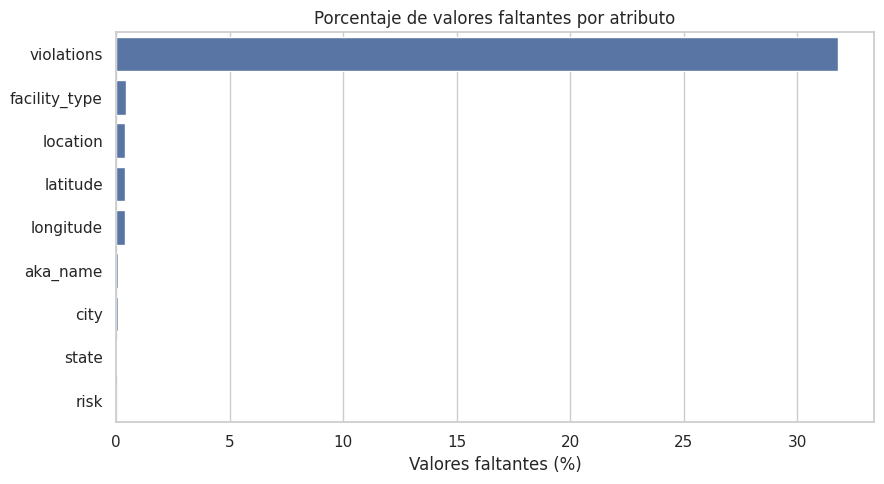

In [6]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=missing_summary,
    x="Porcentaje",
    y="Atributo",
    color="#4C72B0",
)

plt.title("Porcentaje de valores faltantes por atributo")
plt.xlabel("Valores faltantes (%)")
plt.ylabel("")
plt.tight_layout()
plt.show()

`violations` concentra casi todos los faltantes, con cerca de 32 %. En las demás columnas el porcentaje es menor a 1 %. Esto hace pensar que la ausencia de infracciones puede estar relacionada con el tipo de resultado y no solamente con errores de captura.

Para comprobarlo, compararé la ausencia de `violations` con el resultado de la inspección.

In [7]:
missing_by_result = pd.crosstab(
    inspections["results"],
    inspections["violations"].isna(),
    normalize="index",
) * 100

missing_by_result = missing_by_result.rename(
    columns={False: "Con dato", True: "Faltante"}
)

missing_by_result.round(1)

violations,Con dato,Faltante
results,,
Business Not Located,0.0,100.0
Fail,97.5,2.5
No Entry,4.1,95.9
Not Ready,0.5,99.5
Out of Business,0.0,100.0
Pass,71.9,28.1
Pass w/ Conditions,97.2,2.8


Los faltantes no parecen ocurrir al azar. Casi todos los casos `No Entry`, `Not Ready`, `Out of Business` y `Business Not Located` no tienen infracciones registradas. Por eso no sería correcto convertir automáticamente todos estos faltantes en cero.

### 5.2 Registros duplicados

Revisaré tanto filas completamente repetidas como identificadores de inspección duplicados.

In [8]:
duplicate_rows = inspections.duplicated().sum()
duplicate_ids = inspections["inspection_id"].duplicated().sum()

print(f"Filas completamente duplicadas: {duplicate_rows}")
print(f"Identificadores repetidos: {duplicate_ids}")

Filas completamente duplicadas: 0
Identificadores repetidos: 0


No encontré duplicados exactos ni identificadores repetidos. Un nombre de negocio repetido no se considera duplicado, ya que el establecimiento puede haber recibido más de una inspección.

### 5.3 Cardinalidad de las variables categóricas

La cantidad de valores diferentes puede revelar categorías demasiado específicas o escritas de varias formas.

In [9]:
categorical_columns = inspections.select_dtypes(
    include="object"
).columns

categorical_summary = pd.DataFrame(
    {
        "Valores únicos": inspections[
            categorical_columns
        ].nunique(),
        "Valores faltantes": inspections[
            categorical_columns
        ].isna().sum(),
    }
).sort_values("Valores únicos", ascending=False)

categorical_summary

,Valores únicos,Valores faltantes
violations,13047,6113
address,12078,0
location,11949,75
dba_name,10468,0
aka_name,10170,15
facility_type,140,81
city,26,14
inspection_type,12,0
results,7,0
risk,4,3


Es normal que los nombres, direcciones e infracciones tengan una cardinalidad alta. En cambio, `facility_type` tiene 140 categorías, por lo que más adelante sería conveniente comprobar si algunas representan el mismo tipo de establecimiento con distinta escritura.

### 5.4 Inconsistencias y valores sospechosos

Como casi todas las observaciones corresponden a Chicago, revisaré las formas en que aparece escrito el nombre de la ciudad.

In [10]:
inspections["city"].value_counts(
    dropna=False
).head(15)

,count
city,
CHICAGO,19136
Chicago,36
NaN,14
chicago,11
CCHICAGO,4
EVANSTON,3
312CHICAGO,2
CHICAGO.,2
BERWYN,2


Encontré variantes como `CHICAGO`, `Chicago`, `chicago`, `CCHICAGO` y `CHICAGOO`. Varias se refieren a la misma ciudad, así que existe una inconsistencia de codificación.

In [11]:
print("Categorías de riesgo:")
display(inspections["risk"].value_counts(dropna=False))

print("Estados registrados:")
display(inspections["state"].value_counts(dropna=False))

print(
    "Licencias con valor cero:",
    (inspections["license_"] == 0).sum(),
)

Categorías de riesgo:


,count
risk,
Risk 1 (High),15239
Risk 2 (Medium),3099
Risk 3 (Low),877
All,10
NaN,3


Estados registrados:


,count
state,
IL,19220
NaN,4
IN,3
CO,1


Licencias con valor cero: 51


En `risk` aparece la categoría `All`, que no corresponde a uno de los tres niveles normales. También hay algunos domicilios fuera de Illinois y 51 licencias con valor cero. Los considero datos sospechosos, pero no los eliminaré sin conocer primero su significado administrativo.

Finalmente comprobaré si existen coordenadas físicamente imposibles.

In [12]:
invalid_coordinates = inspections[
    (
        inspections["latitude"].notna()
        & ~inspections["latitude"].between(-90, 90)
    )
    | (
        inspections["longitude"].notna()
        & ~inspections["longitude"].between(-180, 180)
    )
]

print(
    "Coordenadas fuera del rango válido:",
    len(invalid_coordinates),
)

Coordenadas fuera del rango válido: 0


No se encontraron coordenadas imposibles. Aun así, hay registros sin ubicación y esta prueba no garantiza que todas las coordenadas correspondan exactamente a Chicago.

## 6. Preparación para el análisis

Conservaré el dataset original y trabajaré sobre una copia. Solo corregiré variantes evidentes de `city` y crearé variables auxiliares.

In [13]:
analysis_data = inspections.copy()

analysis_data["city_clean"] = (
    analysis_data["city"]
    .astype("string")
    .str.strip()
    .str.upper()
    .replace(
        {
            "CCHICAGO": "CHICAGO",
            "CHICAGOO": "CHICAGO",
            "CHICAGO.": "CHICAGO",
            "CHICAGOCHICAGO": "CHICAGO",
            "312CHICAGO": "CHICAGO",
        }
    )
)

# Cada infracción está separada por el símbolo |.
# Los faltantes se conservan porque no significan necesariamente cero.
analysis_data["violation_count"] = (
    analysis_data["violations"]
    .str.count(r"\|")
    .add(1)
)

analysis_data["month"] = (
    analysis_data["inspection_date"].dt.month
)

analysis_data[
    ["city", "city_clean", "violations", "violation_count"]
].head()

,city,city_clean,violations,violation_count
0,CHICAGO,CHICAGO,"55. PHYSICAL FACILITIES INSTALLED, MAINTAINED ...",1.0
1,CHICAGO,CHICAGO,NaN,NaN
2,CHICAGO,CHICAGO,"38. INSECTS, RODENTS, & ANIMALS NOT PRESENT - ...",10.0
3,CHICAGO,CHICAGO,58. ALLERGEN TRAINING AS REQUIRED - Comments: ...,1.0
4,CHICAGO,CHICAGO,37. FOOD PROPERLY LABELED; ORIGINAL CONTAINER ...,3.0


## 7. Análisis univariado

### 7.1 Estadísticos descriptivos

No incluiré identificadores ni códigos postales porque sus promedios no tienen una interpretación útil.

In [14]:
numeric_variables = [
    "latitude",
    "longitude",
    "violation_count",
]

analysis_data[
    numeric_variables
].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
latitude,19153.0,41.88,0.08,41.64,41.83,41.89,41.94,42.02
longitude,19153.0,-87.67,0.06,-87.91,-87.71,-87.66,-87.63,-87.53
violation_count,13115.0,4.61,3.55,1.00,2.00,4.00,6.00,30.00


Entre las inspecciones que sí tienen información de infracciones, la mediana es 4 y el promedio es aproximadamente 4.6. El máximo es 30, lo que indica que existen algunos casos bastante alejados del centro de la distribución.

### 7.2 Resultado de las inspecciones

Esta es la posible variable objetivo, así que revisaré su distribución.

In [15]:
result_summary = pd.DataFrame(
    {
        "Frecuencia": analysis_data["results"].value_counts(),
        "Porcentaje": (
            analysis_data["results"]
            .value_counts(normalize=True)
            * 100
        ),
    }
)

result_summary.round(2)

,Frecuencia,Porcentaje
results,,
Pass,9908,51.53
Fail,3481,18.10
Pass w/ Conditions,2606,13.55
Out of Business,1437,7.47
No Entry,1381,7.18
Not Ready,408,2.12
Business Not Located,7,0.04


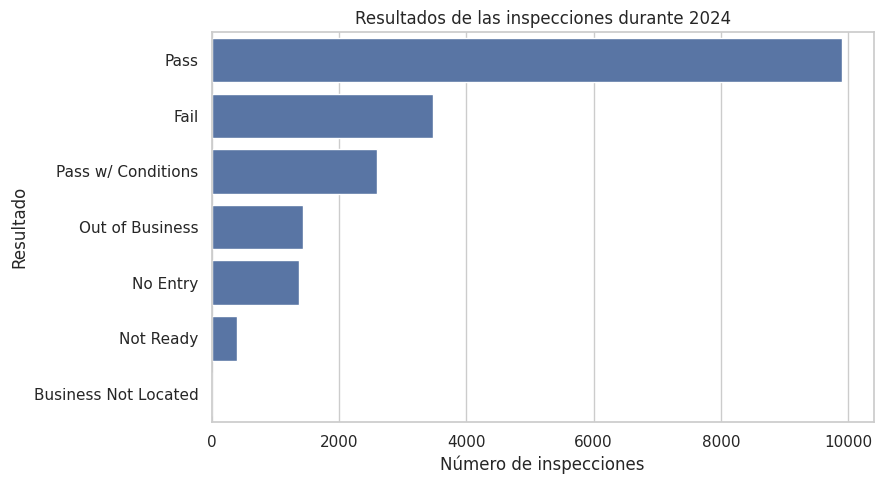

In [16]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=result_summary["Frecuencia"],
    y=result_summary.index,
    color="#4C72B0",
)

plt.title("Resultados de las inspecciones durante 2024")
plt.xlabel("Número de inspecciones")
plt.ylabel("Resultado")
plt.tight_layout()
plt.show()

`Pass` representa poco más de la mitad de todas las inspecciones. Sin embargo, `results` también contiene estados donde la inspección no se completó, por lo que no conviene tratarla directamente como una variable binaria.

### 7.3 Nivel de riesgo

In [17]:
risk_summary = pd.DataFrame(
    {
        "Frecuencia": analysis_data["risk"].value_counts(),
        "Porcentaje": (
            analysis_data["risk"]
            .value_counts(normalize=True)
            * 100
        ),
    }
)

risk_summary.round(2)

,Frecuencia,Porcentaje
risk,,
Risk 1 (High),15239,79.27
Risk 2 (Medium),3099,16.12
Risk 3 (Low),877,4.56
All,10,0.05


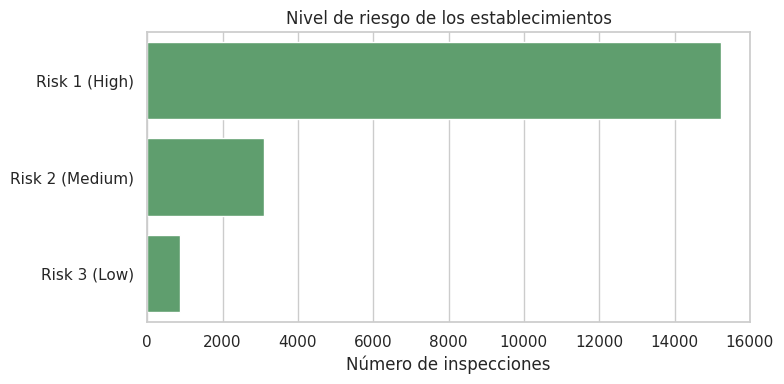

In [18]:
risk_order = [
    "Risk 1 (High)",
    "Risk 2 (Medium)",
    "Risk 3 (Low)",
]

plt.figure(figsize=(8, 4))

sns.countplot(
    data=analysis_data[
        analysis_data["risk"].isin(risk_order)
    ],
    y="risk",
    order=risk_order,
    color="#55A868",
)

plt.title("Nivel de riesgo de los establecimientos")
plt.xlabel("Número de inspecciones")
plt.ylabel("")
plt.tight_layout()
plt.show()

Casi 8 de cada 10 inspecciones corresponden a establecimientos clasificados como riesgo alto. Por eso cualquier comparación entre niveles debe considerar que los grupos tienen tamaños muy diferentes.

### 7.4 Cantidad de infracciones

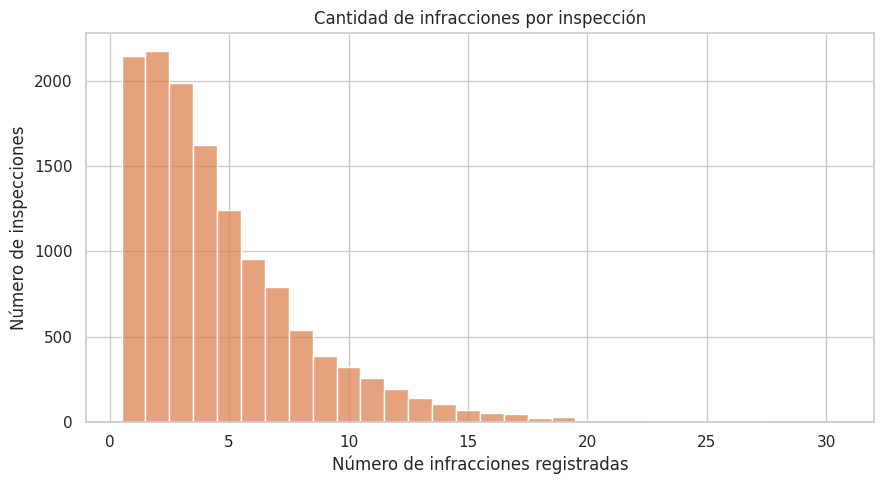

In [19]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=analysis_data,
    x="violation_count",
    discrete=True,
    color="#DD8452",
)

plt.title("Cantidad de infracciones por inspección")
plt.xlabel("Número de infracciones registradas")
plt.ylabel("Número de inspecciones")
plt.tight_layout()
plt.show()

La distribución se concentra en cantidades pequeñas y presenta una cola hacia la derecha. La mayoría de las inspecciones con información tiene pocas infracciones, pero algunos casos llegan a más de 20.

## 8. Análisis bivariado

### 8.1 Infracciones y resultado

Para esta comparación usaré únicamente inspecciones con un resultado completo: aprobar, aprobar con condiciones o reprobar.

In [20]:
completed_results = [
    "Pass",
    "Pass w/ Conditions",
    "Fail",
]

completed = analysis_data[
    analysis_data["results"].isin(completed_results)
    & analysis_data["violation_count"].notna()
].copy()

violation_by_result = (
    completed.groupby("results")["violation_count"]
    .agg(["count", "mean", "median"])
    .reindex(completed_results)
)

violation_by_result.round(2)

,count,mean,median
results,,,
Pass,7128,3.20,3.0
Pass w/ Conditions,2534,5.26,5.0
Fail,3395,7.04,6.0


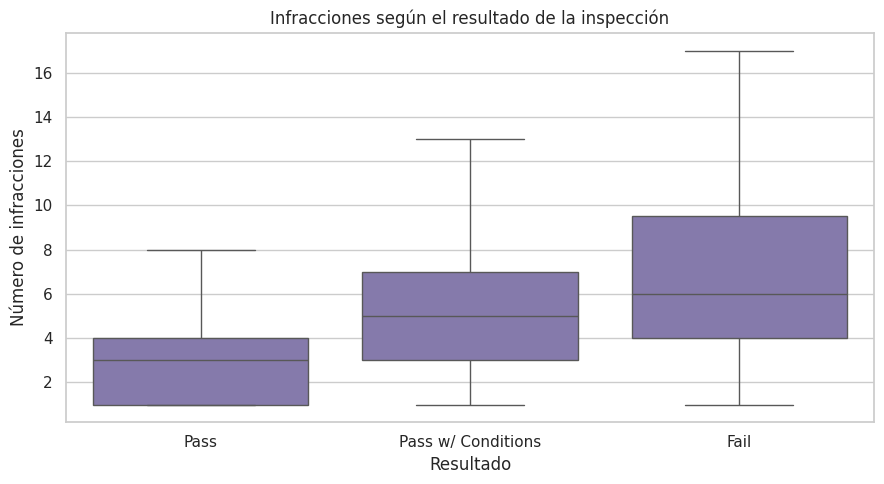

In [21]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=completed,
    x="results",
    y="violation_count",
    order=completed_results,
    color="#8172B3",
    showfliers=False,
)

plt.title("Infracciones según el resultado de la inspección")
plt.xlabel("Resultado")
plt.ylabel("Número de infracciones")
plt.tight_layout()
plt.show()

Las inspecciones aprobadas tienen en promedio cerca de 3.2 infracciones, las aprobadas con condiciones 5.3 y las reprobadas 7.0. La relación tiene sentido: al aumentar las infracciones, el resultado tiende a ser menos favorable. En la gráfica se ocultaron visualmente los puntos extremos para comparar mejor las cajas, pero no se eliminaron de los cálculos.

### 8.2 Nivel de riesgo y resultado

Ahora compararé porcentajes, ya que el número de inspecciones por nivel de riesgo es muy diferente.

In [22]:
risk_result_data = analysis_data[
    analysis_data["results"].isin(completed_results)
    & analysis_data["risk"].isin(risk_order)
]

risk_result_percent = pd.crosstab(
    risk_result_data["risk"],
    risk_result_data["results"],
    normalize="index",
) * 100

risk_result_percent = risk_result_percent.reindex(
    index=risk_order,
    columns=completed_results,
)

risk_result_percent.round(2)

results,Pass,Pass w/ Conditions,Fail
risk,,,
Risk 1 (High),61.79,16.27,21.94
Risk 2 (Medium),62.32,17.02,20.65
Risk 3 (Low),63.62,13.93,22.45


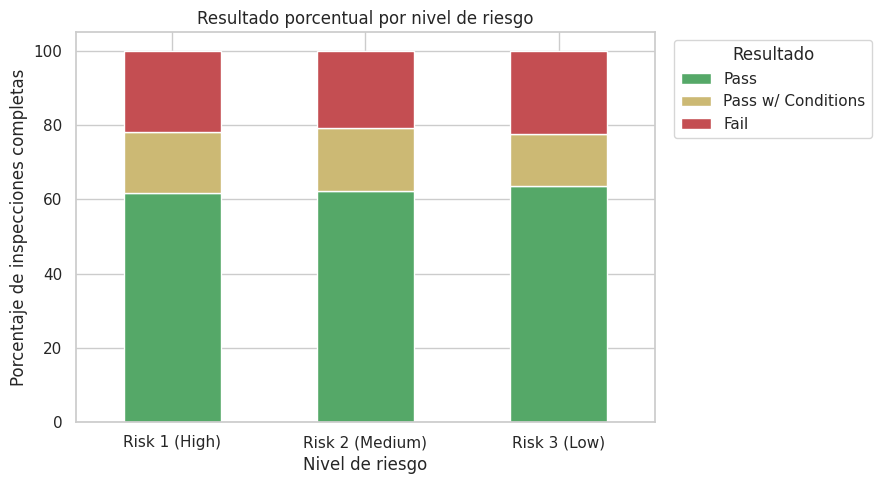

In [23]:
risk_result_percent.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5),
    color=["#55A868", "#CCB974", "#C44E52"],
)

plt.title("Resultado porcentual por nivel de riesgo")
plt.xlabel("Nivel de riesgo")
plt.ylabel("Porcentaje de inspecciones completas")
plt.xticks(rotation=0)
plt.legend(title="Resultado", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

Entre las inspecciones completas, los porcentajes son bastante parecidos en los tres niveles. El riesgo alto describe el tipo de establecimiento y no garantiza por sí mismo que una inspección vaya a reprobarse.

### 8.3 Mes y porcentaje de reprobación

También revisaré si el porcentaje de inspecciones reprobadas cambió durante el año.

In [24]:
monthly_data = analysis_data[
    analysis_data["results"].isin(completed_results)
].copy()

monthly_data["failed"] = (
    monthly_data["results"] == "Fail"
)

monthly_summary = monthly_data.groupby("month").agg(
    Inspecciones=("inspection_id", "size"),
    Porcentaje_reprobado=("failed", "mean"),
)

monthly_summary["Porcentaje_reprobado"] *= 100
monthly_summary.round(2)

,Inspecciones,Porcentaje_reprobado
month,,
1,1202,26.96
2,1190,25.29
3,1323,23.28
4,1612,22.70
5,1524,19.95
6,1052,22.62
7,1333,21.23
8,1301,22.37
9,1422,20.25


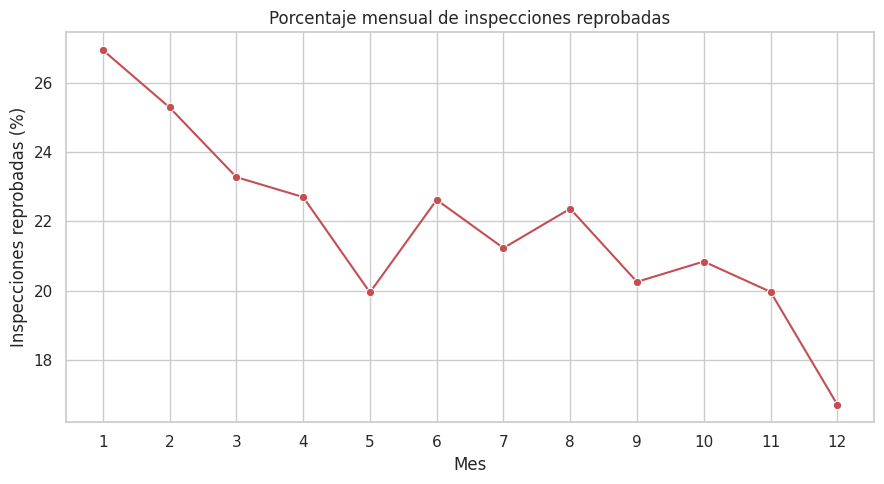

In [25]:
plt.figure(figsize=(9, 5))

sns.lineplot(
    data=monthly_summary,
    x=monthly_summary.index,
    y="Porcentaje_reprobado",
    marker="o",
    color="#C44E52",
)

plt.title("Porcentaje mensual de inspecciones reprobadas")
plt.xlabel("Mes")
plt.ylabel("Inspecciones reprobadas (%)")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

El porcentaje de reprobación fue mayor al inicio de 2024 y menor en diciembre. Con un solo año no puedo afirmar que exista una tendencia permanente o un efecto estacional; también podría cambiar la mezcla de establecimientos o tipos de inspección de cada mes.

## 9. Vista multivariada

Combinaré el nivel de riesgo, el resultado y el promedio de infracciones. El color representará la tercera variable.

In [26]:
multivariate_data = analysis_data[
    analysis_data["risk"].isin(risk_order)
    & analysis_data["results"].isin(completed_results)
]

violation_pivot = pd.pivot_table(
    multivariate_data,
    index="risk",
    columns="results",
    values="violation_count",
    aggfunc="mean",
    observed=True,
)

violation_pivot = violation_pivot.reindex(
    index=risk_order,
    columns=completed_results,
)

violation_pivot.round(2)

results,Pass,Pass w/ Conditions,Fail
risk,,,
Risk 1 (High),3.26,5.47,7.06
Risk 2 (Medium),3.03,4.37,7.06
Risk 3 (Low),2.62,4.14,6.72


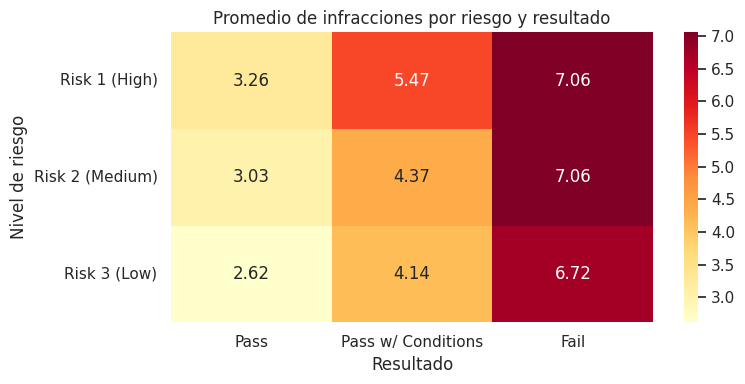

In [27]:
plt.figure(figsize=(8, 4))

sns.heatmap(
    violation_pivot,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
)

plt.title("Promedio de infracciones por riesgo y resultado")
plt.xlabel("Resultado")
plt.ylabel("Nivel de riesgo")
plt.tight_layout()
plt.show()

En los tres niveles de riesgo se repite el mismo patrón: los casos reprobados tienen más infracciones, después aparecen los aprobados con condiciones y finalmente los aprobados. En esta vista, el resultado parece estar más relacionado con la cantidad de infracciones que con el nivel de riesgo del establecimiento.

## 10. Hallazgos principales

1. `Pass` es el resultado más común, pero solo representa cerca del 52 % del total porque también existen inspecciones no completadas.
2. Las inspecciones reprobadas tienen alrededor de 7 infracciones en promedio, frente a aproximadamente 3.2 en las aprobadas.
3. Cerca del 79 % de las inspecciones corresponde a establecimientos de riesgo alto, aunque el porcentaje de reprobación entre los tres niveles es parecido cuando solo se comparan inspecciones completas.
4. Los faltantes de `violations` siguen un patrón: se concentran en resultados como `No Entry`, `Not Ready` y `Out of Business`.

## 11. Preguntas que abre el dataset

- ¿Qué tipos de establecimiento tienen una mayor probabilidad de reprobar?
- ¿Las inspecciones de seguimiento mejoran el resultado anterior de un negocio?
- ¿Existen zonas de Chicago con más inspecciones reprobadas?
- ¿El cambio mensual observado también aparece en otros años?

## 12. Problemas que deberían corregirse antes de continuar

- Estandarizar categorías de `city` y revisar las 140 formas de `facility_type`.
- Investigar el significado de `risk = All` y de las licencias con valor cero.
- Decidir cómo tratar `violations` según el resultado, evitando convertir todos los faltantes en cero.
- Validar los domicilios fuera de Illinois y los registros sin coordenadas.
- Considerar que varias inspecciones pueden pertenecer al mismo negocio y, por lo tanto, no siempre son observaciones independientes.

## 13. Cierre

El dataset cumple con los requisitos y permite observar problemas reales de calidad. El análisis mostró una relación clara entre el número de infracciones y el resultado, pero también dejó dudas sobre los faltantes, las categorías de ubicación y la forma en que se define el nivel de riesgo.

Antes de construir un modelo sería necesario resolver esos problemas y definir con cuidado qué resultados representan inspecciones realmente completadas. Tampoco se deben interpretar las relaciones encontradas como causas, ya que este análisis solamente describe los registros disponibles.

## Referencias

- City of Chicago. [Food Inspections](https://data.cityofchicago.org/Health-Human-Services/Food-Inspections/4ijn-s7e5).
- City of Chicago. [Data Terms of Use](https://www.chicago.gov/city/en/narr/foia/data_disclaimer.html).
- Broad Institute of MIT and Harvard. [Coding and Comment Style](https://mitcommlab.mit.edu/broad/commkit/coding-and-comment-style/).

### Nota sobre el uso de inteligencia artificial

Para la elaboración de esta práctica utilicé GPT SOL, como herramienta de apoyo en la organización y redacción del contenido. Le compartí mi archivo de trabajo con el código, los resultados obtenidos y mis notas preliminares; a partir de ese material, me ayudó a ordenar las ideas, estructurar las secciones, proponer títulos y mejorar la ortografía y claridad de los textos. Finalmente, revisé y adapté cada apartado para asegurar que las explicaciones representaran correctamente lo observado durante el análisis.
